In [19]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))
import importlib
import processing, simulation
importlib.reload(simulation)
importlib.reload(processing)
from simulation import generate_time_vector, generate_glucose_signal
from processing import simulate_sensor_lag, add_sensor_noise, add_sensor_drift, simulate_raw_sensor

In [13]:
time = generate_time_vector()

glucose = generate_glucose_signal(time)

sensor = simulate_sensor_lag(glucose, alpha=0.2)

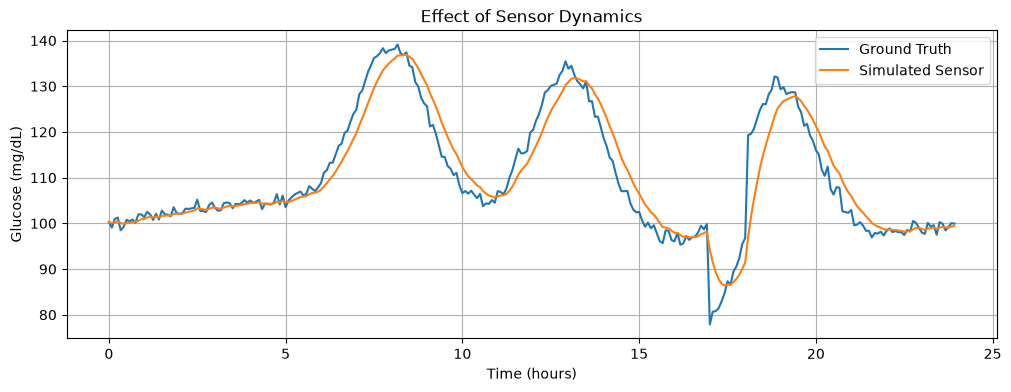

In [14]:
plt.figure(figsize = (12,4))
plt.plot(time/60, glucose, label = "Ground Truth")
plt.plot(time/60, sensor, label = 'Simulated Sensor')

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Effect of Sensor Dynamics")
plt.legend()
plt.grid(True)

plt.show()

In [15]:
noisy_sensor = add_sensor_noise(
    sensor,
    noise_std =3,
    random_seed=42
)

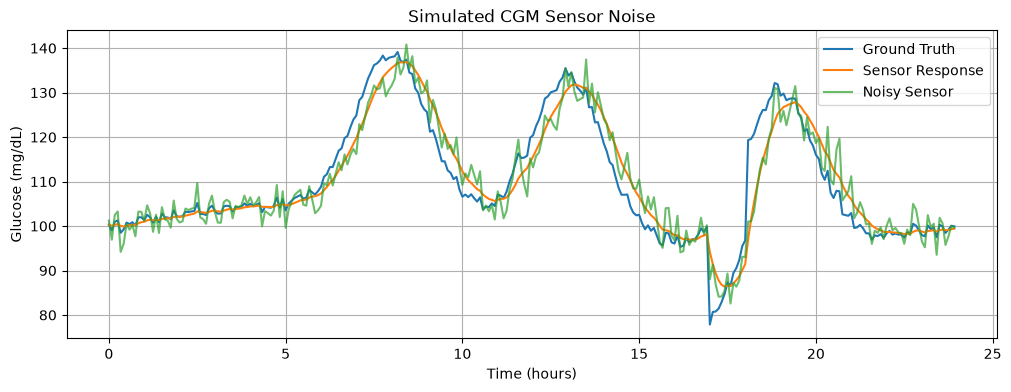

In [16]:
plt.figure(figsize=(12, 4))

plt.plot(
    time / 60,
    glucose,
    label="Ground Truth",
)

plt.plot(
    time / 60,
    sensor,
    label="Sensor Response",
)

plt.plot(
    time / 60,
    noisy_sensor,
    label="Noisy Sensor",
    alpha=0.7,
)

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Simulated CGM Sensor Noise")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
drifted_sensor = add_sensor_drift(
    noisy_sensor,
    sampling_interval_minutes = 5,
    drift_rate=0.5
)

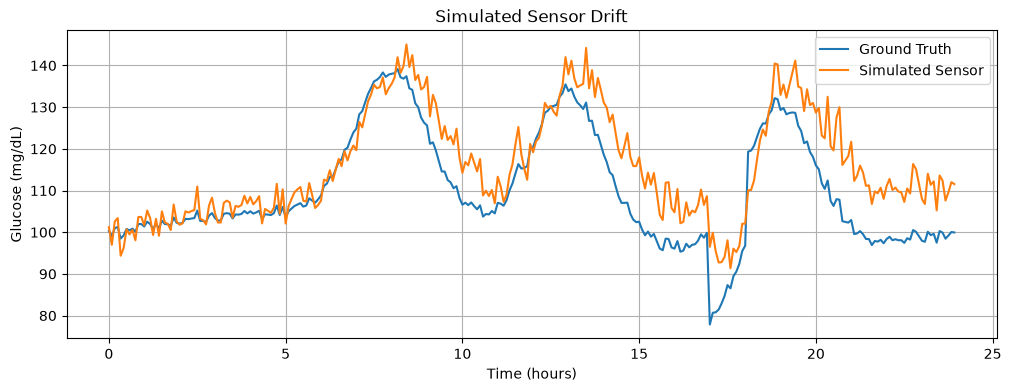

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(
    time / 60,
    glucose,
    label="Ground Truth",
)

plt.plot(
    time / 60,
    drifted_sensor,
    label="Simulated Sensor",
)

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Simulated Sensor Drift")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
raw_sensor = simulate_raw_sensor(
    glucose,
    alpha=0.2,
    noise_std=3.0,
    sampling_interval_minutes=5.0,
    drift_rate=0.5,
    random_seed=42,
)

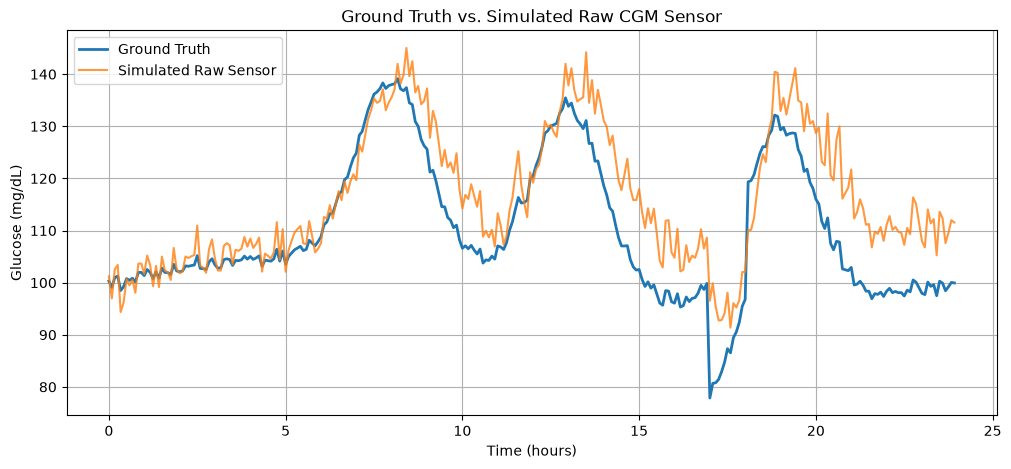

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(
    time / 60,
    glucose,
    label="Ground Truth",
    linewidth=2,
)

plt.plot(
    time / 60,
    raw_sensor,
    label="Simulated Raw Sensor",
    alpha=0.8,
)

plt.xlabel("Time (hours)")
plt.ylabel("Glucose (mg/dL)")
plt.title("Ground Truth vs. Simulated Raw CGM Sensor")
plt.legend()
plt.grid(True)

plt.show()